<a href="https://colab.research.google.com/github/joyangelai/Colabs-Vol-2/blob/main/Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes Classification

A. The Gaussian Naive Bayes classifier is a popular machine learning algorithm based on the principles of Bayes' theorem and the assumption of Gaussian (normal) distribution of the features. It is a supervised learning algorithm used for classification tasks, where the goal is to predict the class label of an input instance based on its feature values

1. Assumption of Independence: The "naive" part of Gaussian Naive Bayes comes from the assumption that all features are independent of each other given the class label.

2. Training Phase: During the training phase, the algorithm estimates the mean and variance of each feature for each class in the training data. This means that for each class, the algorithm calculates the mean and variance of each feature by considering only the instances belonging to that class.

3. Gaussian Probability Density Function (PDF): Since the algorithm assumes that the features are Gaussian-distributed, it uses the probability density function (PDF) of a Gaussian distribution to model the likelihood of observing a particular feature value for each class.

4. Bayes' Theorem: calculate the posterior probability of each class given the input features.

5. Classification Decision: Finally, the classifier selects the class label with the highest posterior probability as the predicted class for the input instance.

B. Multinomial Naive Bayes (MNB) is another variant of the Naive Bayes classifier, particularly suited for text classification and problems with discrete feature values. It is an extension of the basic Naive Bayes algorithm, but instead of assuming Gaussian distribution for continuous features, it assumes a multinomial distribution for discrete features.

Here's how Multinomial Naive Bayes works:

1. Feature Representation:
MNB is commonly used for text classification, where the input features typically represent word frequencies or counts in a document. It assumes that the features are discrete, non-negative integers, such as word counts or term frequencies.


2. Training Phase:
During the training phase, MNB estimates the probabilities of observing each feature value (word) in each class label based on the training data. It calculates the class priors (prior probabilities of each class) and the conditional probabilities of each feature value given the class label.

3. Multinomial Probability Model:
MNB models the likelihood of observing a particular feature value (word count) as a multinomial probability distribution. It counts the occurrences of each word in each class and normalizes the counts to obtain probabilities.

4. Assumption of Feature Independence:
Like the Gaussian Naive Bayes, MNB also assumes feature independence, meaning the occurrence of one word in a document is independent of the occurrences of other words, given the class label. This assumption simplifies the computation and is the reason for the term "naive" in Naive Bayes.

5. Bayes' Theorem:
Once the probabilities for each feature value and class are estimated, Bayes' theorem is used to calculate the posterior probability of each class given the input features.

6. Classification Decision:
The class with the highest posterior probability is selected as the predicted class for the input instance.

Multinomial Naive Bayes has been widely used in natural language processing (NLP) tasks like text classification, sentiment analysis, spam detection, and topic modeling. It is computationally efficient, particularly with high-dimensional data such as text data, and can work well with relatively small training datasets.

Recall that Bayes' theorem is:  

$$ \Large P(A|B) = \frac{P(B|A)\bullet P(A)}{P(B)}$$

expanding to multiple features, Gaussian Naive Bayes (Calculate conditional probability point estimates)

$$ \Large P(x_i|y) = \frac{1}{\sqrt{2 \pi \sigma_i^2}}e^{\frac{-(x-\mu_i)^2}{2\sigma_i^2}}$$

Expanding to multiple features, the multinomial Bayes' formula is:  

$$ \Large P(y|x_1, x_2, ..., x_n) = \frac{P(y)\prod_{i}^{n}P(x_i|y)}{P(x_1, x_2, ..., x_n)}$$

Naives Bayes Classifier hands on

link to the dataset download: https://www.kaggle.com/datasets/tmehul/spamcsv?select=spam.csv

In [ ]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

#Impelmantation usking sklearnlearn train-test split method

In [ ]:
#load the dataset
df = pd.read_csv("/content/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
#checking the null values
df.isnull().sum()

,0
label,0
message,0


In [ ]:
# checking the shape
df.shape

(5572, 2)

In [ ]:
# check columns
df.columns

Index(['label', 'message'], dtype='object')

In [ ]:
#dropping the columns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis= 1, inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Renaming the 'v1' and 'v2' columns
#df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
# Displaying the updated DataFrame
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# encoding label column
enc = LabelEncoder()
df['label'] = enc.fit_transform(df['label'])
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Dividing data into target and feature variables
#X, Y = df.message, df.label
X, y = df.message, df.label
X.tail()

,message
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...
5571,Rofl. Its true to its name


In [ ]:
#splitting the data into train and test data set
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4457,), (1115,), (4457,), (1115,))

In [ ]:
#vectorizer the train set
#vectorizer = CountVectorizer()
#count = vectorizer.fit_transform(X_train.values)
vectorizer = CountVectorizer()
count = vectorizer.fit_transform(X_train.values)
X_test_v = vectorizer.transform(X_test.values)

In [ ]:
#checking the count  --> this is x_train
#count
count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58978 stored elements and shape (4457, 7735)>

In [ ]:
#calling the model
#clf= MultinomialNB()
#targets = Y_train.values   --> this is similar to encoding using labelencoder, you can say label.values, this isnt a must step
#clf.fit(count, targets)
clf = MultinomialNB()
targets = y_train.values
clf.fit(count, targets)  # targets is y_train


MultinomialNB()

In [ ]:
#checking the prediction
#y_pred = clf.predict(vectorizer.transform(X_test))
y_pred = clf.predict(X_test_v)
print(pd.DataFrame(y_pred[:5]))
y_train[:5]

   0
0  0
1  0
2  1
3  0
4  1


,label
1978,0
3989,1
3935,0
4078,0
4086,1


In [ ]:
#metrics
print(confusion_matrix(y_test, y_pred))

[[963   2]
 [ 16 134]]


In [ ]:
#accuracy score
print(f"{accuracy_score(y_test, y_pred) * 100:.2f}%")

98.39%


In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
# check roc score
print(roc_auc_score(y_test, y_pred))

0.9456303972366149


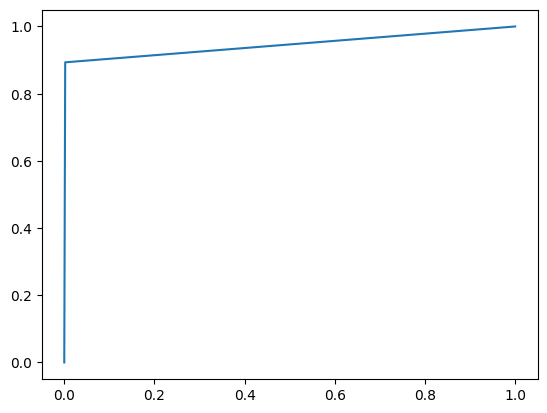

In [ ]:
# plot roc curve
fpr, tpr, threshold = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)

2. Implementing the same process using CV Technqinue

In [ ]:
#load the dataset
data = pd.read_csv("spam.csv", encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Rename columns 'v1' to 'label' and 'v2' to 'email'
data.rename(columns={'v1': 'label', 'v2': 'email'}, inplace=True)
data.head()

In [ ]:
# Drop unnamed columns from the dataset
def drop_unnamed_columns(data):
    return data.drop(columns=data.columns[data.columns.str.contains('Unnamed')], inplace=True, axis=1)

# Call the function to drop unnamed columns
drop_unnamed_columns(data)

In [ ]:
#checking the dataset
data.head()

In [ ]:
#seperating the dataset into features and target variable
X, y = data.email, data.label

In [ ]:
#splitting the data into train and test using cv
# Import the StratifiedKFold class
from sklearn.model_selection import StratifiedKFold

# Create a StratifiedKFold object with the desired number of folds (e.g., 5)
num_folds = 5
stratified_kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lists to store training and test indices for each fold
train_list = []
test_list = []

# Perform stratified cross-validation
for train_indices, test_indices in stratified_kf.split(X, y):
    train_list.append(train_indices)
    test_list.append(test_indices)



In [ ]:
# Now, you can access the indices for each fold to split your data
for fold in range(num_folds):
    X_train_cv = X.iloc[train_list[fold]]
    X_test_cv = X.iloc[test_list[fold]]
    y_train_cv = y.iloc[train_list[fold]]
    y_test_cv = y.iloc[test_list[fold]]

In [ ]:
 # vectorize the text
vectorizer = CountVectorizer()
X_train_cv_counts = vectorizer.fit_transform(X_train_cv)

In [ ]:
#checking the count
X_train_cv_counts

In [ ]:
# Your classifier and model training code here using X_train_cv, y_train_cv, X_test_cv, and y_test_cv
clf = MultinomialNB()
X_train_cv_counts = vectorizer.fit_transform(X_train_cv)
X_test_cv_counts = vectorizer.transform(X_test_cv)

In [ ]:
# Train the classifier on the training data
clf.fit(X_train_cv_counts, y_train_cv)

In [ ]:
# Make predictions on the test data
y_pred_cv = clf.predict(X_test_cv_counts)

In [ ]:
# Compute the confusion matrix
confusion_mat = confusion_matrix(y_test_cv, y_pred_cv)

# Display the confusion matrix
print("Confusion Matrix:")
print(confusion_mat)


In [ ]:
# Calculate the accuracy
accuracy = accuracy_score(y_test_cv, y_pred_cv)

# Display the accuracy
print("Accuracy:", accuracy)

Advantages of using Gaussian|Multinomial Naive Bayes:

* It is relatively easy to train.
* It is often very accurate.
* It is not computationally expensive.

Disadvantages of using Gaussian|Aultinomial Naive Bayes:

* It can be sensitive to outliers in the data.
* It does not take into account the relationships between features.
* It can be difficult to interpret the results of the classifier.